In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import os
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Your custom modules
from summary_stats import *
from NN_emulator import *
from mcmc_calibration import MCMCCalibration

# Optional
try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False
    print("Install corner for corner plots: pip install corner")

# Set seeds
np.random.seed(42)
from utils import *

2026-02-03 17:00:17.183778: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-03 17:00:17.227611: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print("="*70)
print("LOADING DATA")
print("="*70)

# Load parameters
info = pd.read_csv('data/info.txt', delimiter=r'\s+')
ocn_columns = [col for col in info.columns if col.startswith('ocn.')]
columns_to_keep = ['runid'] + ocn_columns
if 'ocn.l_noise_fw' in columns_to_keep:
    columns_to_keep.remove('ocn.l_noise_fw')
params = info[columns_to_keep]

print(f"Parameters shape: {params.shape}")

# %%
# Load model files
model_files = []
missing_ids = []

for run_id in range(1, 501):
    file_path = f"data/{run_id}/ocn_ts.nc"
    if os.path.exists(file_path):
        model_files.append(file_path)
    else:
        missing_ids.append(run_id)
        model_files.append(None)

print(f"Found {sum(f is not None for f in model_files)} runs, missing {len(missing_ids)}")


LOADING DATA
Parameters shape: (500, 7)
Found 483 runs, missing 17


In [3]:
# Load default (target) run
print("\nLoading default run...")
apply_filter = True

ds_default = xr.open_dataset("../default_long_run/ocn_ts.nc")
amoc_default = ds_default.amoc26N.values
time_default = ds_default.time.values
ds_default.close()

if apply_filter:
    amoc_default_processed = lowpass_filter(amoc_default, cutoff_years=100)
else:
    amoc_default_processed = amoc_default

default_stats = compute_summary_stats(amoc_default_processed, time_default)
print(f"Default: {default_stats['n_stadials']} stadials, "
      f"waiting time={default_stats['avg_waiting_time']:.1f}yr")

# %%
# Load ensemble runs
print("\nLoading ensemble runs...")

ensemble_stats = []
for i, file in enumerate(model_files):
    if file:
        try:
            ds = xr.open_dataset(file)
            amoc = ds.amoc26N.values
            time = ds.time.values
            ds.close()
            
            if apply_filter:
                amoc = lowpass_filter(amoc, cutoff_years=100)
            
            stats = compute_summary_stats(amoc, time)
            ensemble_stats.append(stats)
        except:
            ensemble_stats.append(None)
    else:
        ensemble_stats.append(None)

print(f"Loaded {sum(s is not None for s in ensemble_stats)} members")


Loading default run...
Default: 52 stadials, waiting time=1452.0yr

Loading ensemble runs...
Loaded 483 members


In [4]:
# Fit PCA on ensemble PDFs
print("\nFitting PCA on ensemble PDFs...")

pdf_pca_components = 5
all_pdfs = [stats['pdf'] for stats in ensemble_stats if stats is not None]

pca_model = PCA(n_components=pdf_pca_components)
pca_model.fit(np.array(all_pdfs))

print(f"PCA explained variance: {pca_model.explained_variance_ratio_}")
print(f"Total variance explained: {pca_model.explained_variance_ratio_.sum():.3f}")

# Add PCA components to stats
default_stats['pca_components'] = pca_model.transform(default_stats['pdf'].reshape(1, -1)).flatten()

for stats in ensemble_stats:
    if stats is not None:
        stats['pca_components'] = pca_model.transform(stats['pdf'].reshape(1, -1)).flatten()



Fitting PCA on ensemble PDFs...
PCA explained variance: [0.43511648 0.16012526 0.12019246 0.09022088 0.06871605]
Total variance explained: 0.874


In [5]:
# Define DO behavior mask
print("\nIdentifying DO-oscillating runs...")

min_stadials_threshold = 27

has_DO_behavior = np.array([
    s['n_stadials'] >= min_stadials_threshold if s else False 
    for s in ensemble_stats
])

# Remove spurious runs
spurious_runs = np.array([
    s['n_stadials'] >= 75 if s else False
    for s in ensemble_stats
])
spurious2 = [7, 10, 27, 40, 127, 205, 206, 222, 239, 244, 255, 257, 292, 368, 414, 421, 441, 445, 447, 474, 475]

has_DO_behavior[spurious2] = False
has_DO_behavior[np.where(spurious_runs)] = False

print(f"Total runs: {len(ensemble_stats)}")
print(f"DO-oscillating runs: {has_DO_behavior.sum()} ({100*has_DO_behavior.sum()/len(ensemble_stats):.1f}%)")

# %% [markdown]


Identifying DO-oscillating runs...
Total runs: 500
DO-oscillating runs: 322 (64.4%)


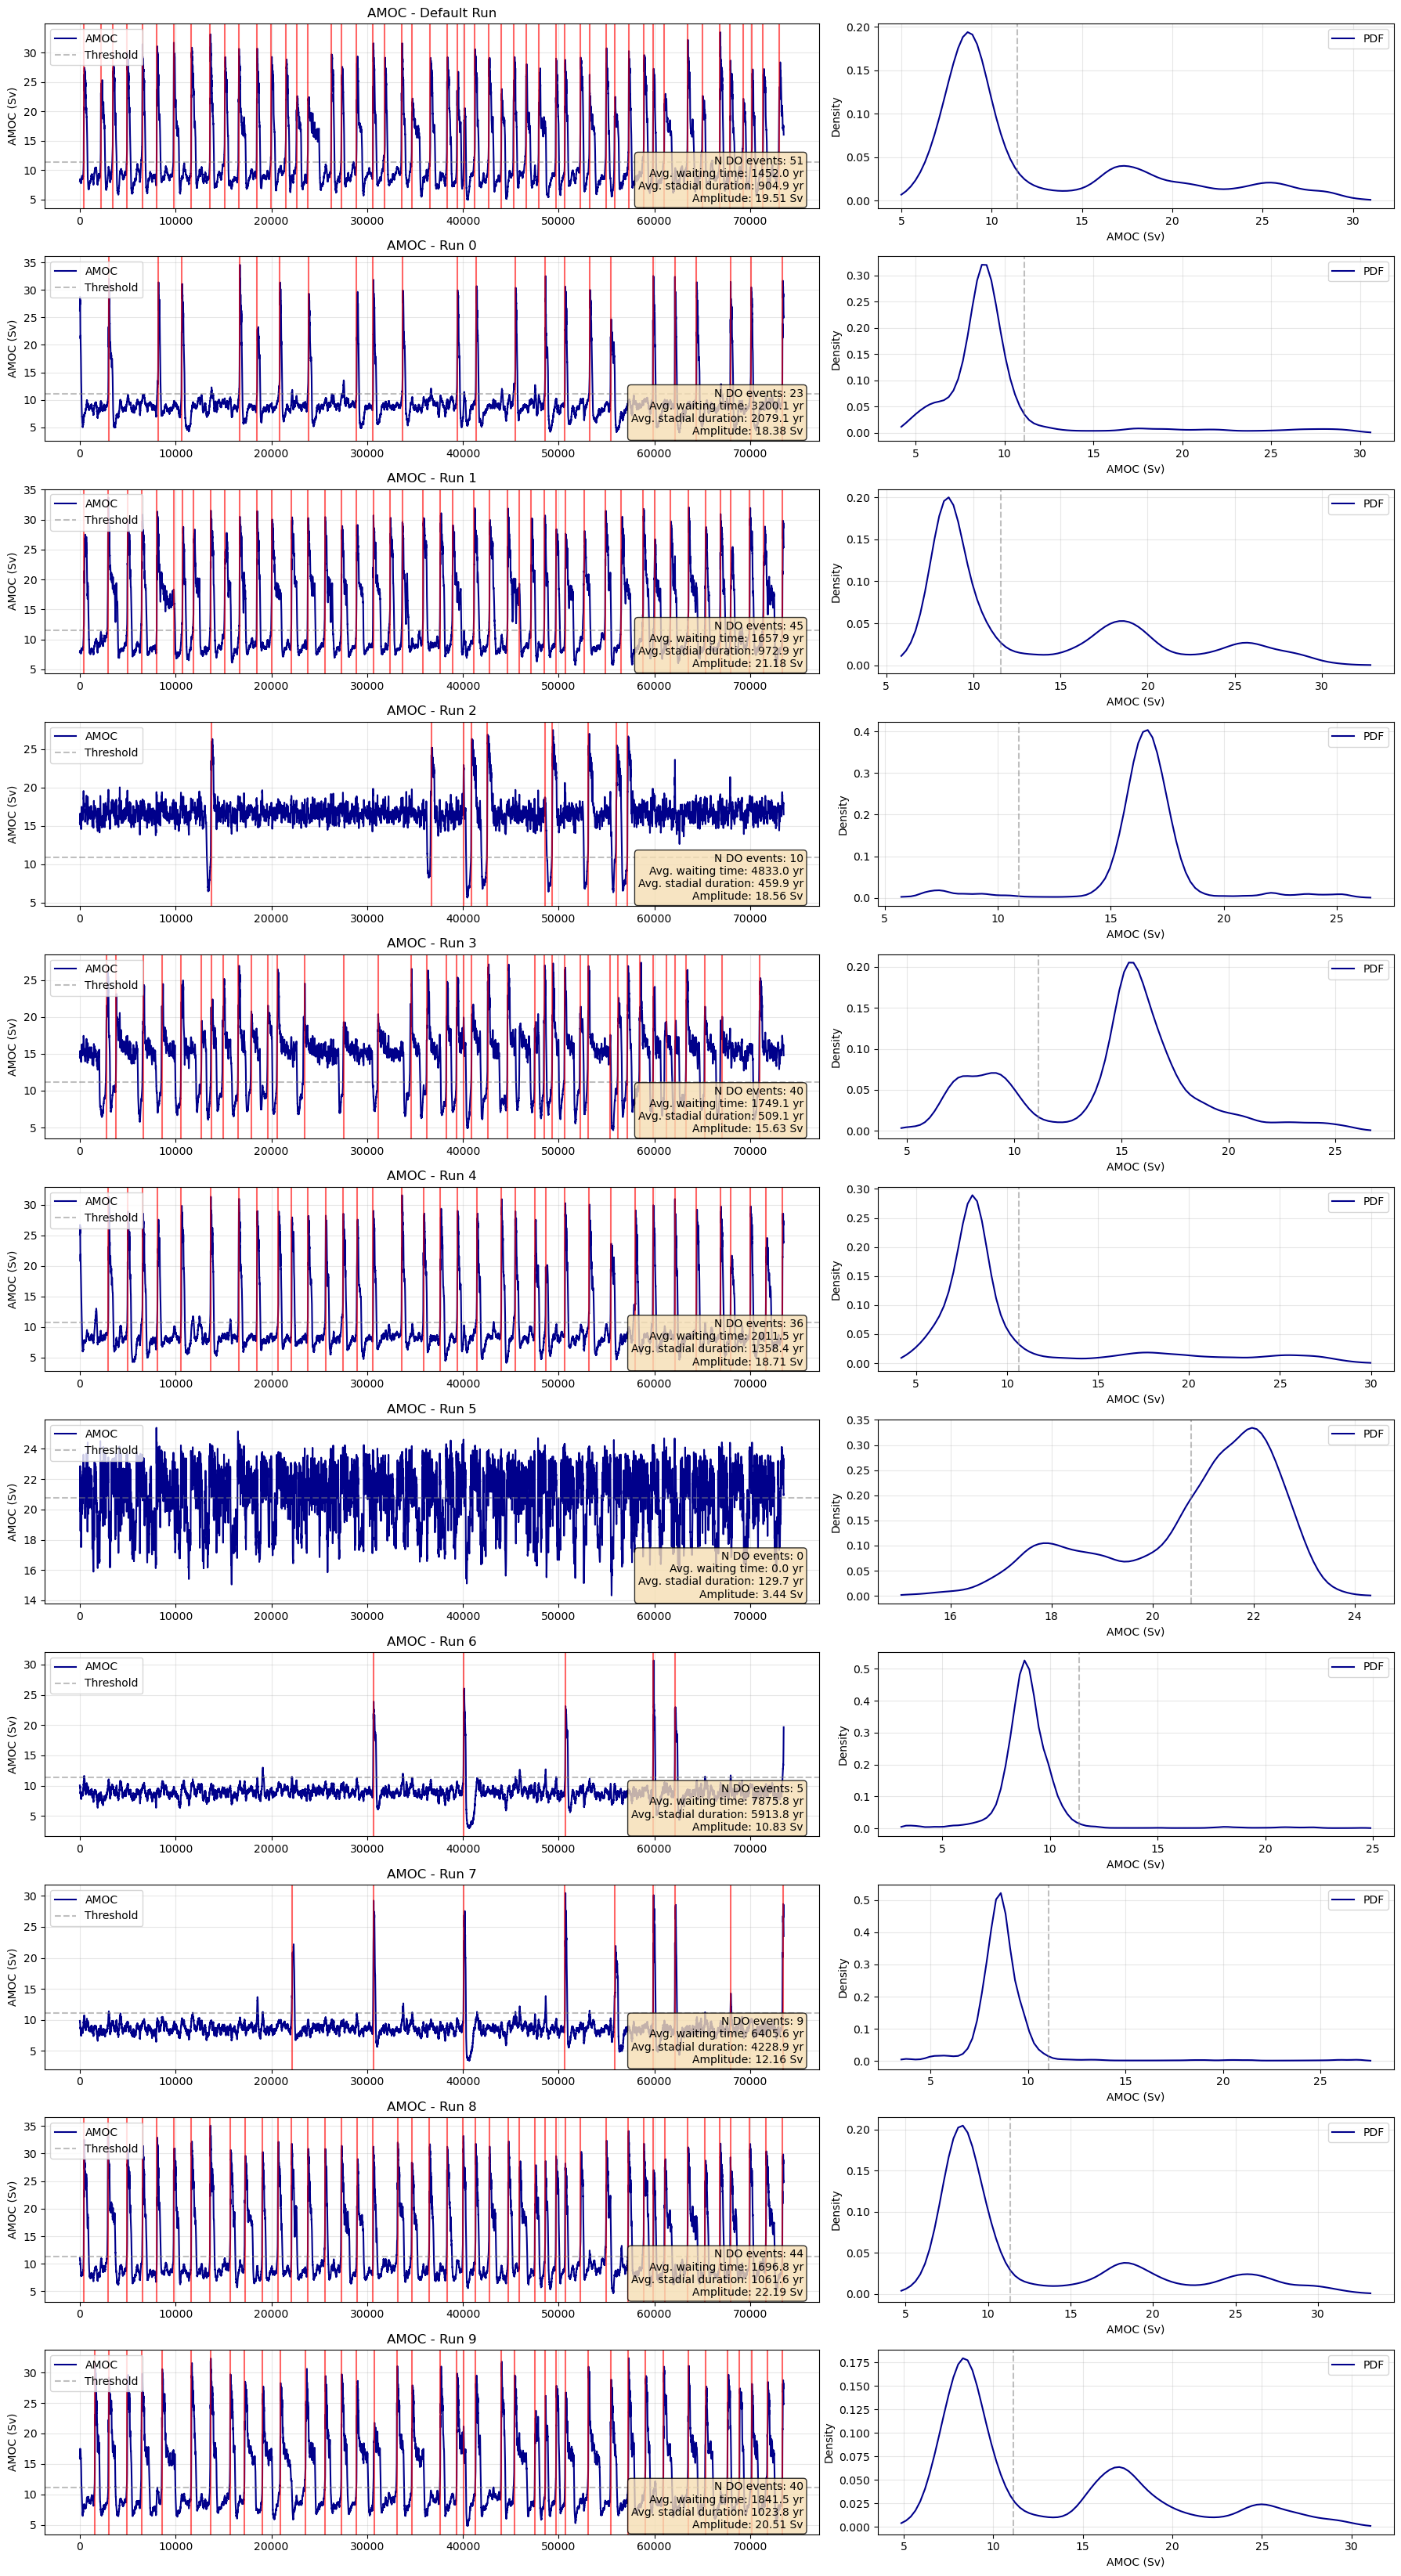

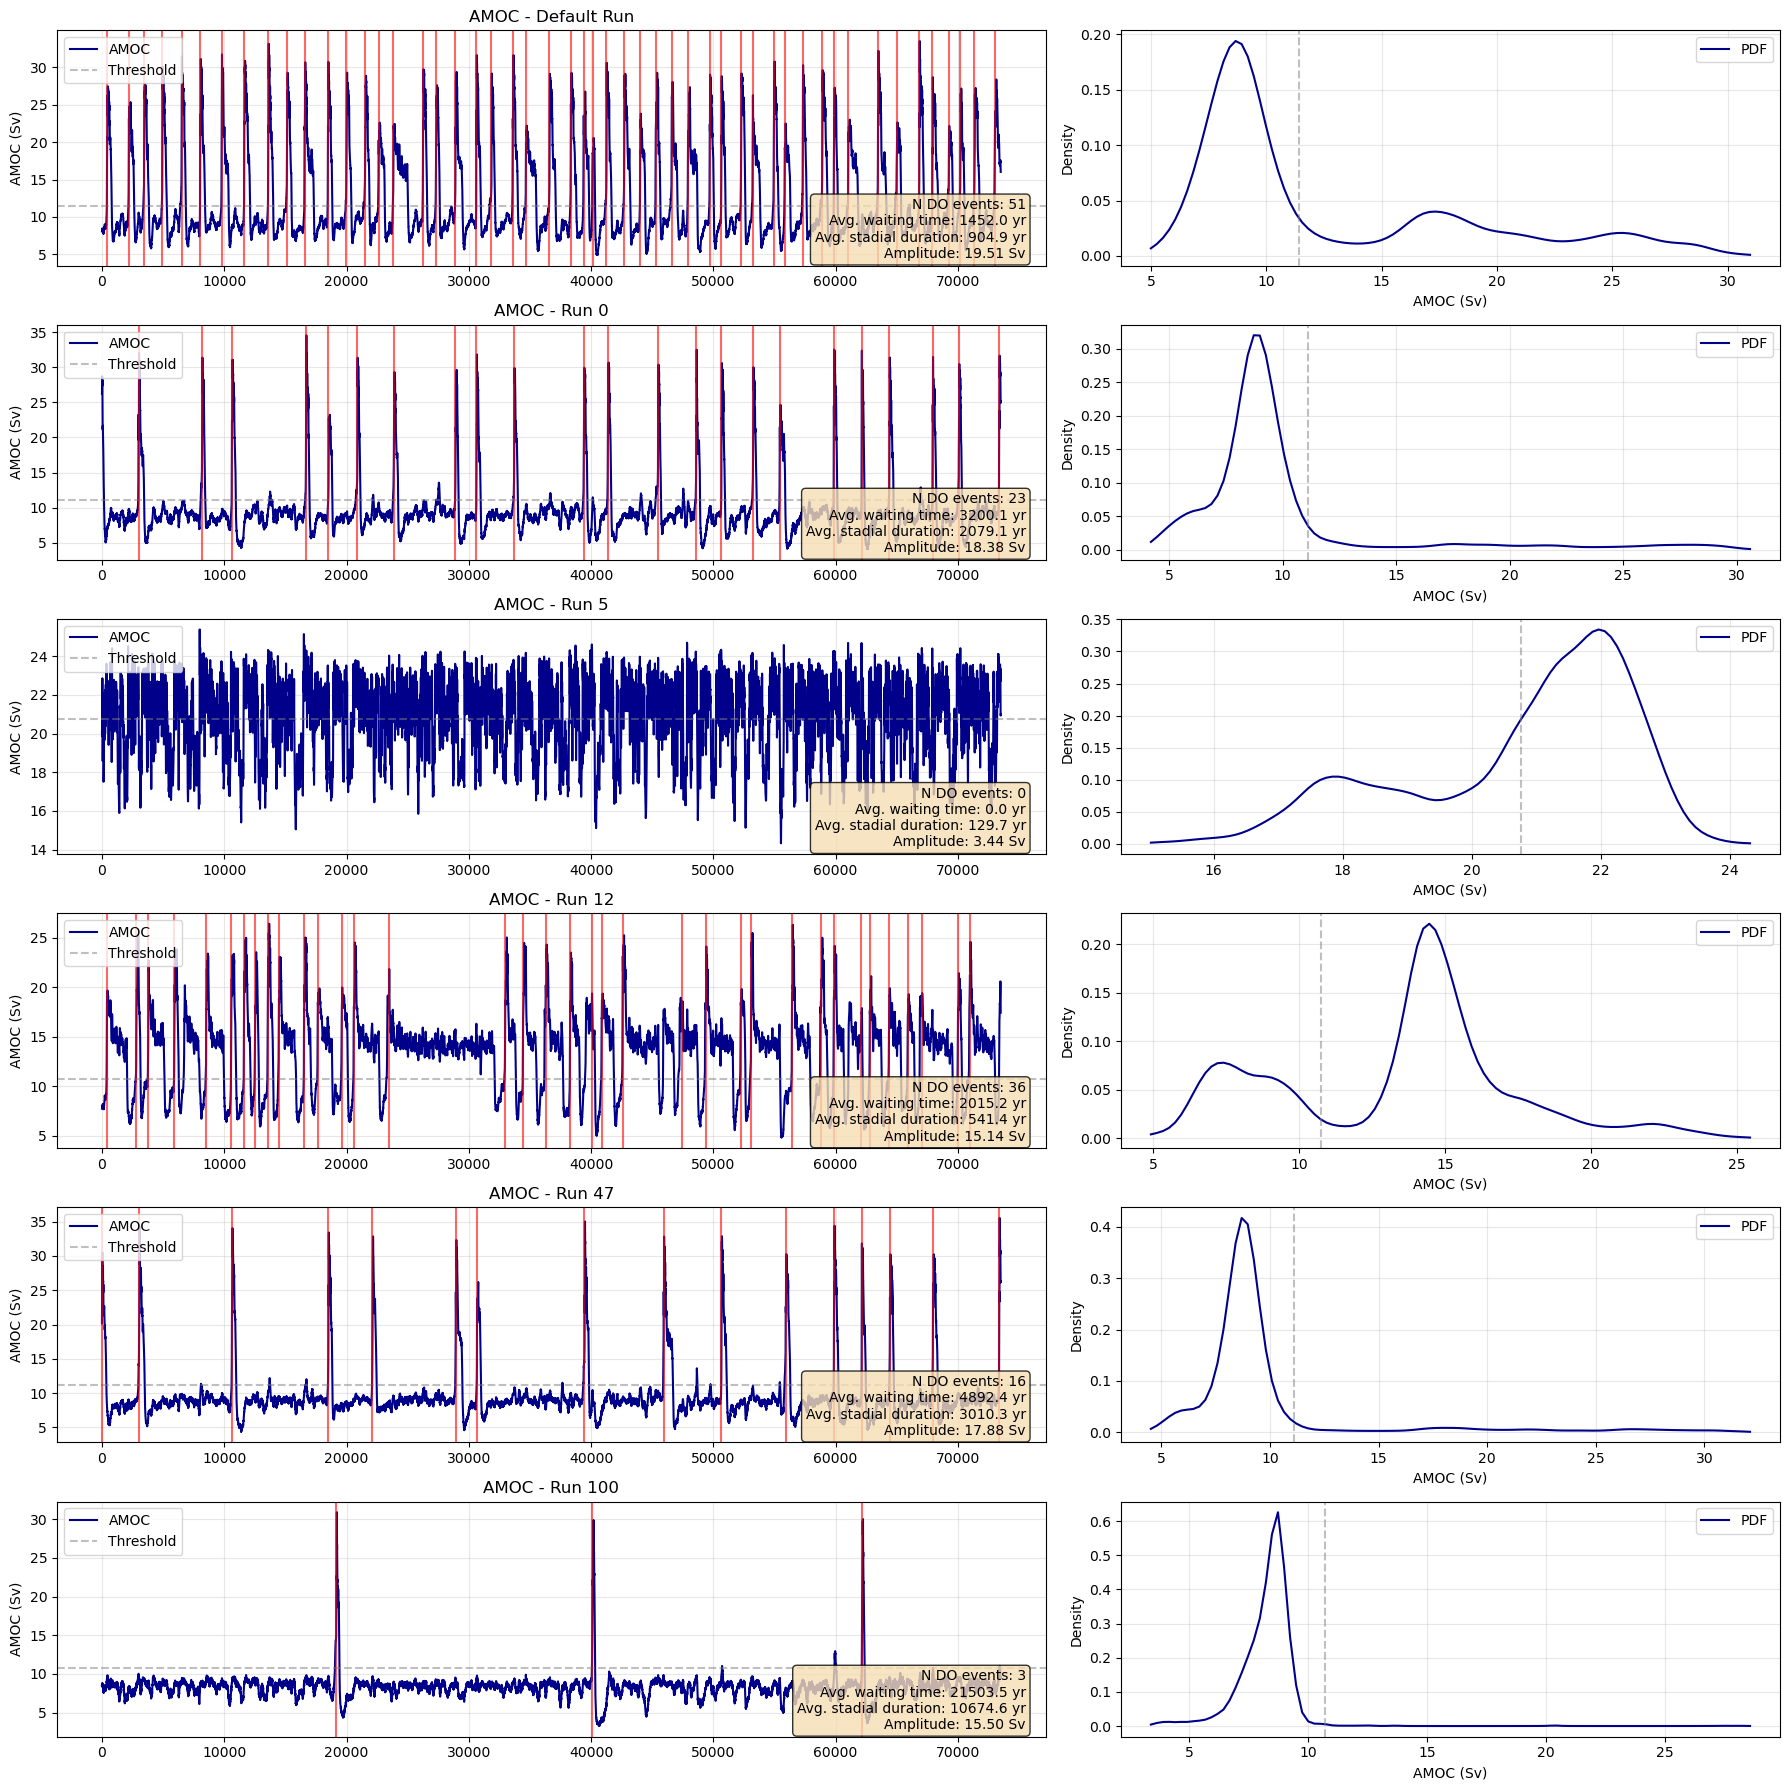

In [6]:
# Option 1: Plot first n runs
fig, axes = plot_amoc_analysis(
    ensemble_stats, model_files,
    default_stats=default_stats, default_file="../default_long_run/ocn_ts.nc",
    n_runs=10
)

# Option 2: Plot specific run IDs
fig, axes = plot_amoc_analysis(
    ensemble_stats, model_files,
    default_stats=default_stats, default_file="../default_long_run/ocn_ts.nc",
    run_ids=[0, 5, 12, 47, 100]
)

# Try penalty approach with GP

In [7]:
# ----------------------------
# 1. Prepare data
# ----------------------------
# Filter out None entries in ensemble_stats
valid = [s is not None for s in ensemble_stats]
ensemble_stats_valid = [s for s in ensemble_stats if s is not None]
params_valid = params[valid]
has_DO_behavior_valid = has_DO_behavior[valid]

param_cols = [
    'ocn.diff_dia_min', 'ocn.drag_topo_fac', 'ocn.slope_max',
    'ocn.diff_iso', 'ocn.diff_gm', 'ocn.diff_dia_max'
]
X = params_valid[param_cols].values

other_stats = np.array([
    [s['mean'], s['std'],
     s['avg_stadial_duration'], s['avg_waiting_time'],
     s['avg_amplitude'], s['n_stadials']]
    for s in ensemble_stats_valid
])

# Extract PCA components
pca_components = np.array([s['pca_components'] for s in ensemble_stats_valid])

# Filter for DO behavior
X_DO = X[has_DO_behavior_valid]
other_stats_DO = other_stats[has_DO_behavior_valid]
pca_components_DO = pca_components[has_DO_behavior_valid]
ensemble_stats_DO = [
    s for s, m in zip(ensemble_stats_valid, has_DO_behavior_valid) if m
]

# Set final X and other_stats
X = X_DO
other_stats = other_stats_DO
pca_components = pca_components_DO

print(f"Number of DO runs: {len(X_DO)}")

# ----------------------------
# 2. Assemble PDFs
# ----------------------------
pdf_matrix = np.array([s['pdf'] for s in ensemble_stats_valid])  # shape (n_runs, n_grid)
pdf_matrix = pdf_matrix[has_DO_behavior_valid]

print(f"PDF matrix shape: {pdf_matrix.shape}")
print(f"PCA components shape: {pca_components.shape}")

Number of DO runs: 322
PDF matrix shape: (322, 100)
PCA components shape: (322, 5)


SETTING UP PENALTY-BASED EMULATOR

Defining observational targets from sliding window analysis...

Observational Targets Summary:
------------------------------------------------------------
  pca_components: 5 components
    [0]: 0.1625 ± 0.0100 (±2σ: [0.1425, 0.1825])
    [1]: -0.1352 ± 0.0050 (±2σ: [-0.1452, -0.1252])
    [2]: -0.0558 ± 0.0100 (±2σ: [-0.0758, -0.0358])
    [3]: -0.0528 ± 0.0030 (±2σ: [-0.0588, -0.0468])
    [4]: -0.0584 ± 0.0050 (±2σ: [-0.0684, -0.0484])
  avg_waiting_time: 1451.9600 ± 42.3600 (±2σ: [1367.2400, 1536.6800])
  avg_stadial_duration: 904.9423 ± 34.9400 (±2σ: [835.0623, 974.8223])
  mean: 12.6006 ± 0.0300 (±2σ: [12.5406, 12.6606])
  std: 6.1311 ± 0.0300 (±2σ: [6.0711, 6.1911])
  avg_amplitude: 19.5079 ± 0.6800 (±2σ: [18.1479, 20.8679])
  n_stadials: 52.0000 ± 1.8600 (±2σ: [48.2800, 55.7200])

Setting up penalty calculator...
Penalty metrics: ['penalty_pca_components_0', 'penalty_pca_components_1', 'penalty_pca_components_2', 'penalty_pca_components_3', '

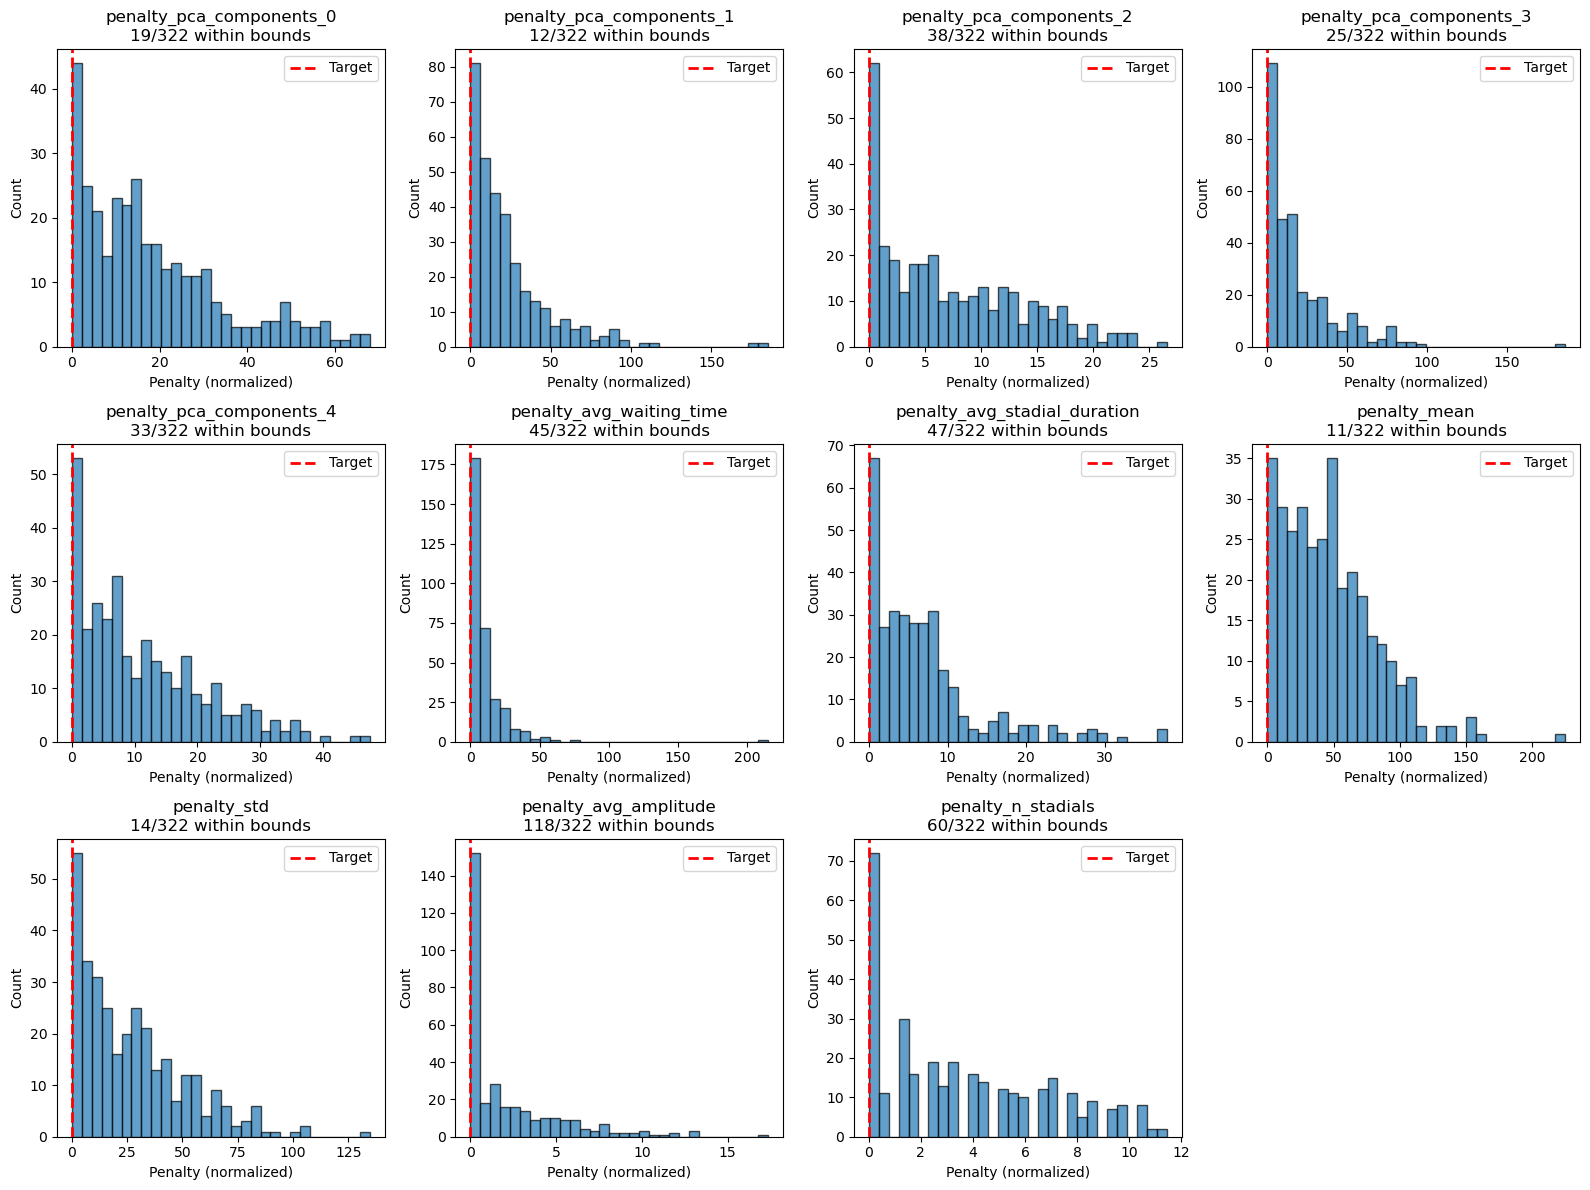


DEFAULT RUN PENALTIES
Default run should have ~0 penalties (it's the target):
  penalty_pca_components_0: 0.000000
  penalty_pca_components_1: 0.000000
  penalty_pca_components_2: 0.000000
  penalty_pca_components_3: 0.000000
  penalty_pca_components_4: 0.000000
  penalty_avg_waiting_time: 0.000000
  penalty_avg_stadial_duration: 0.000000
  penalty_mean: 0.000000
  penalty_std: 0.000000
  penalty_avg_amplitude: 0.000000
  penalty_n_stadials: 0.000000

Total penalty: 0.000000


In [8]:
# =============================================================================
# NOTEBOOK WORKFLOW: PENALTY-BASED EMULATOR WITH YOUR UNCERTAINTIES
# =============================================================================
from penalty_emulator import *
print("="*70)
print("SETTING UP PENALTY-BASED EMULATOR")
print("="*70)

# ----------------------------
# 1. Define observational targets with your uncertainties
# ----------------------------
print("\nDefining observational targets from sliding window analysis...")

obs_targets = setup_DO_targets(default_stats, n_sigma=2)
obs_targets.print_summary()

# ----------------------------
# 2. Set up penalty calculator
# ----------------------------
print("\nSetting up penalty calculator...")

# use_flat_penalty=True means 0 penalty within ±2σ of target
# use_flat_penalty=False means continuous squared error (no flat region)
penalty_calculator = PenaltyCalculator(obs_targets, use_flat_penalty=True)

print(f"Penalty metrics: {penalty_calculator.penalty_names}")
print(f"Total number of penalty dimensions: {len(penalty_calculator.penalty_names)}")

# ----------------------------
# 3. Prepare model values and compute penalties
# ----------------------------
print("\nComputing penalties for ensemble...")

# Convert ensemble stats to the required format
model_values_list = prepare_model_values_list(ensemble_stats_DO, pca_components)

# Compute penalty matrix
penalty_matrix = penalty_calculator.compute_penalties_batch(model_values_list)

print(f"Penalty matrix shape: {penalty_matrix.shape}")

# ----------------------------
# 4. Examine penalty distributions
# ----------------------------
print("\n" + "="*70)
print("PENALTY STATISTICS")
print("="*70)

for i, name in enumerate(penalty_calculator.penalty_names):
    vals = penalty_matrix[:, i]
    n_zero = np.sum(vals == 0)
    print(f"  {name}:")
    print(f"    mean={vals.mean():.4f}, std={vals.std():.4f}")
    print(f"    min={vals.min():.4f}, max={vals.max():.4f}")
    print(f"    within bounds (penalty=0): {n_zero}/{len(vals)} ({100*n_zero/len(vals):.1f}%)")

# ----------------------------
# 5. Visualize penalty distributions
# ----------------------------
n_penalties = len(penalty_calculator.penalty_names)
n_cols = 4
n_rows = int(np.ceil(n_penalties / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, name in enumerate(penalty_calculator.penalty_names):
    ax = axes[i]
    vals = penalty_matrix[:, i]
    
    # Plot histogram
    ax.hist(vals, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Target')
    
    # Add stats
    n_zero = np.sum(vals == 0)
    ax.set_xlabel('Penalty (normalized)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}\n{n_zero}/{len(vals)} within bounds')
    ax.legend()

# Hide unused axes
for i in range(n_penalties, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('Results/penalty_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------
# 6. Check default run penalties
# ----------------------------
print("\n" + "="*70)
print("DEFAULT RUN PENALTIES")
print("="*70)

default_model_values = {
    'pca_components': default_stats['pca_components'],
    'avg_waiting_time': default_stats['avg_waiting_time'],
    'avg_stadial_duration': default_stats['avg_stadial_duration'],
    'mean': default_stats['mean'],
    'std': default_stats['std'],
    'avg_amplitude': default_stats['avg_amplitude'],
    'n_stadials': default_stats['n_stadials']
}

default_penalties = penalty_calculator.compute_penalties(default_model_values)

print("Default run should have ~0 penalties (it's the target):")
for i, name in enumerate(penalty_calculator.penalty_names):
    print(f"  {name}: {default_penalties[i]:.6f}")

total_default = np.sqrt(np.sum(default_penalties**2))
print(f"\nTotal penalty: {total_default:.6f}")


TRAINING PENALTY EMULATOR
Train size: 257, Test size: 65
Penalty dimensions: 11
Fitted GP emulator for 11 penalty metrics

PENALTY EMULATOR EVALUATION

Per-penalty metrics:
  penalty_pca_components_0: RMSE=0.0929, R²=0.547, MAE=0.0732
  penalty_pca_components_1: RMSE=0.0651, R²=0.649, MAE=0.0466
  penalty_pca_components_2: RMSE=0.0757, R²=-0.279, MAE=0.0629
  penalty_pca_components_3: RMSE=0.0469, R²=0.205, MAE=0.0328
  penalty_pca_components_4: RMSE=0.0559, R²=-0.461, MAE=0.0443
  penalty_avg_waiting_time: RMSE=0.5872, R²=0.552, MAE=0.4688
  penalty_avg_stadial_duration: RMSE=0.3893, R²=0.581, MAE=0.3185
  penalty_mean: RMSE=157.3814, R²=0.612, MAE=100.9780
  penalty_std: RMSE=337.7875, R²=0.378, MAE=252.0517
  penalty_avg_amplitude: RMSE=1.0501, R²=0.722, MAE=0.8223
  penalty_n_stadials: RMSE=5.1718, R²=0.200, MAE=4.1706

Overall: RMSE=112.3702, R²=0.683


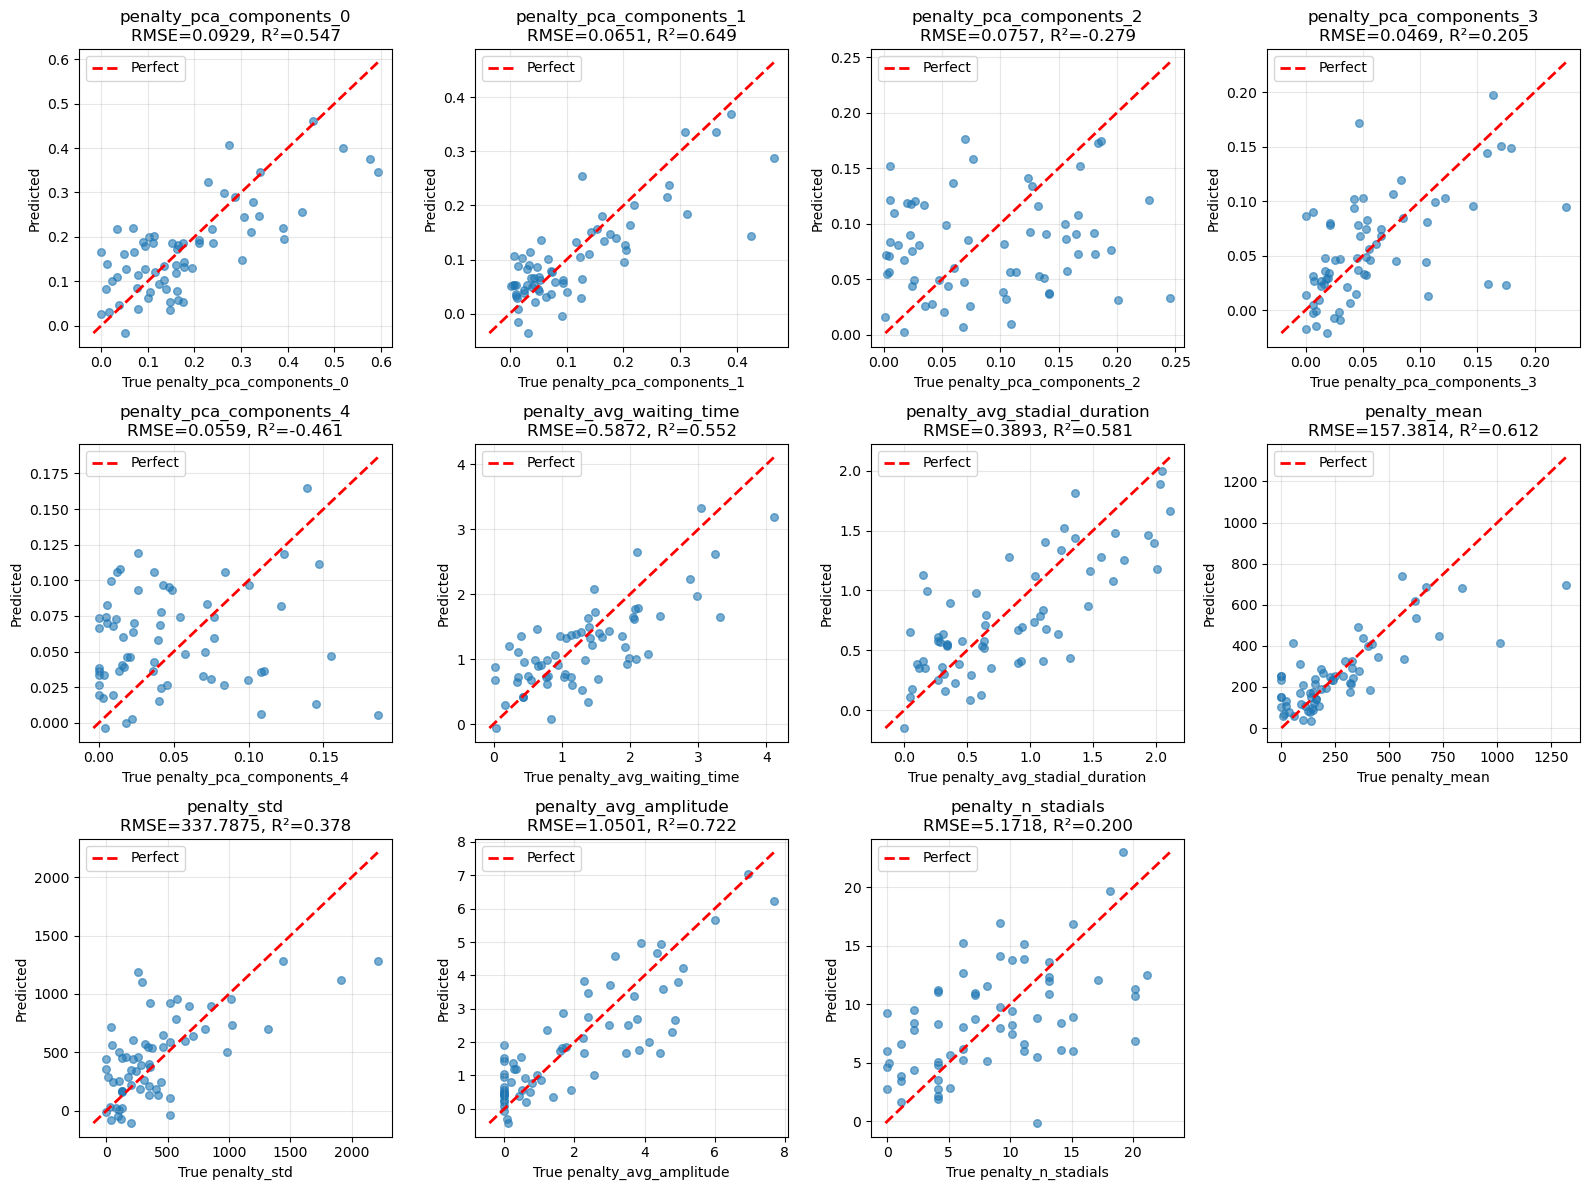

In [16]:
# =============================================================================
# TRAIN AND EVALUATE PENALTY EMULATOR
# =============================================================================

print("\n" + "="*70)
print("TRAINING PENALTY EMULATOR")
print("="*70)

# ----------------------------
# 1. Train-test split
# ----------------------------
X_train, X_test, pen_train, pen_test = train_test_split(
    X, penalty_matrix, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Penalty dimensions: {pen_train.shape[1]}")

# ----------------------------
# 2. Fit penalty emulator
# ----------------------------
kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-5)

penalty_emulator = GPEmulatorPenalty(
    kernel=kernel, 
    penalty_names=penalty_calculator.penalty_names
)
penalty_emulator.fit(X_train, pen_train)

# ----------------------------
# 3. Evaluate on test set
# ----------------------------
print("\n" + "="*70)
print("PENALTY EMULATOR EVALUATION")
print("="*70)

pen_pred, pen_std = penalty_emulator.predict(X_test, return_std=True)

print("\nPer-penalty metrics:")
for i, name in enumerate(penalty_calculator.penalty_names):
    rmse = np.sqrt(mean_squared_error(pen_test[:, i], pen_pred[:, i]))
    r2 = r2_score(pen_test[:, i], pen_pred[:, i]) if np.var(pen_test[:, i]) > 0 else np.nan
    mae = np.mean(np.abs(pen_test[:, i] - pen_pred[:, i]))
    print(f"  {name}: RMSE={rmse:.4f}, R²={r2:.3f}, MAE={mae:.4f}")

# Overall metrics
overall_rmse = np.sqrt(mean_squared_error(pen_test.flatten(), pen_pred.flatten()))
overall_r2 = r2_score(pen_test.flatten(), pen_pred.flatten())
print(f"\nOverall: RMSE={overall_rmse:.4f}, R²={overall_r2:.3f}")

# ----------------------------
# 4. Plot predictions vs true
# ----------------------------
n_penalties = len(penalty_calculator.penalty_names)
n_cols = 4
n_rows = int(np.ceil(n_penalties / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, name in enumerate(penalty_calculator.penalty_names):
    ax = axes[i]
    
    true_vals = pen_test[:, i]
    pred_vals = pen_pred[:, i]
    
    ax.scatter(true_vals, pred_vals, alpha=0.6, s=30)
    
    # Perfect prediction line
    all_vals = np.concatenate([true_vals, pred_vals])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
    
    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    r2 = r2_score(true_vals, pred_vals) if np.var(true_vals) > 0 else np.nan
    
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Predicted')
    ax.set_title(f'{name}\nRMSE={rmse:.4f}, R²={r2:.3f}')
    ax.grid(alpha=0.3)
    ax.legend()

for i in range(n_penalties, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('Results/penalty_emulator_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# Try penalty approach with NN

In [9]:
 # 5. Compute Penalty Metrics

# %%
print("="*70)
print("COMPUTING PENALTY METRICS")
print("="*70)

# Parameter setup
param_cols = [
    'ocn.diff_dia_min', 'ocn.drag_topo_fac', 'ocn.slope_max',
    'ocn.diff_iso', 'ocn.diff_gm', 'ocn.diff_dia_max'
]

# Observational uncertainties (from your sliding window analysis)
obs_uncertainties = {
    'pca_0': 0.01,
    'pca_1': 0.005,
    'pca_2': 0.01,
    'pca_3': 0.003,
    'pca_4': 0.005,
    'mean': 0.03,
    'std': 0.03,
    'avg_stadial_duration': 34.94,
    'avg_waiting_time': 42.36,
    'avg_amplitude': 0.68,
    'n_stadials': 1.86,
}

scalar_stat_names = ['mean', 'std', 'avg_stadial_duration', 
                     'avg_waiting_time', 'avg_amplitude', 'n_stadials']

# Filter valid runs
valid_mask = np.array([s is not None for s in ensemble_stats])
combined_mask = valid_mask & has_DO_behavior

X_all = params[param_cols].values
X_valid = X_all[combined_mask]
ensemble_stats_valid = [s for s, m in zip(ensemble_stats, combined_mask) if m]

print(f"Valid DO runs: {X_valid.shape[0]}")

# %%
# Compute penalties
penalty_list = []

for stats in ensemble_stats_valid:
    run_penalties = []
    
    # PCA component penalties
    for j in range(pdf_pca_components):
        target = default_stats['pca_components'][j]
        model_val = stats['pca_components'][j]
        unc = obs_uncertainties.get(f'pca_{j}', 0.01)
        penalty = compute_penalty(model_val, target + unc, target - unc)
        run_penalties.append(penalty)
    
    # Scalar statistic penalties
    for name in scalar_stat_names:
        target = default_stats[name]
        model_val = stats[name]
        unc = obs_uncertainties.get(name, np.abs(target) * 0.1)
        penalty = compute_penalty(model_val, target + unc, target - unc)
        run_penalties.append(penalty)
    
    penalty_list.append(run_penalties)

penalty_matrix = np.array(penalty_list)

# Output names
output_names = [f'PCA_{i+1}' for i in range(pdf_pca_components)] + scalar_stat_names

print(f"Penalty matrix shape: {penalty_matrix.shape}")
print(f"Output names: {output_names}")

COMPUTING PENALTY METRICS
Valid DO runs: 322
Penalty matrix shape: (322, 11)
Output names: ['PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'mean', 'std', 'avg_stadial_duration', 'avg_waiting_time', 'avg_amplitude', 'n_stadials']


In [10]:
# # 6. Train-Test Split

# %%
X_train, X_test, y_train, y_test = train_test_split(
    X_valid, penalty_matrix, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 257 samples
Test set: 65 samples



PPE CORRELATION ANALYSIS (Figure 2a)


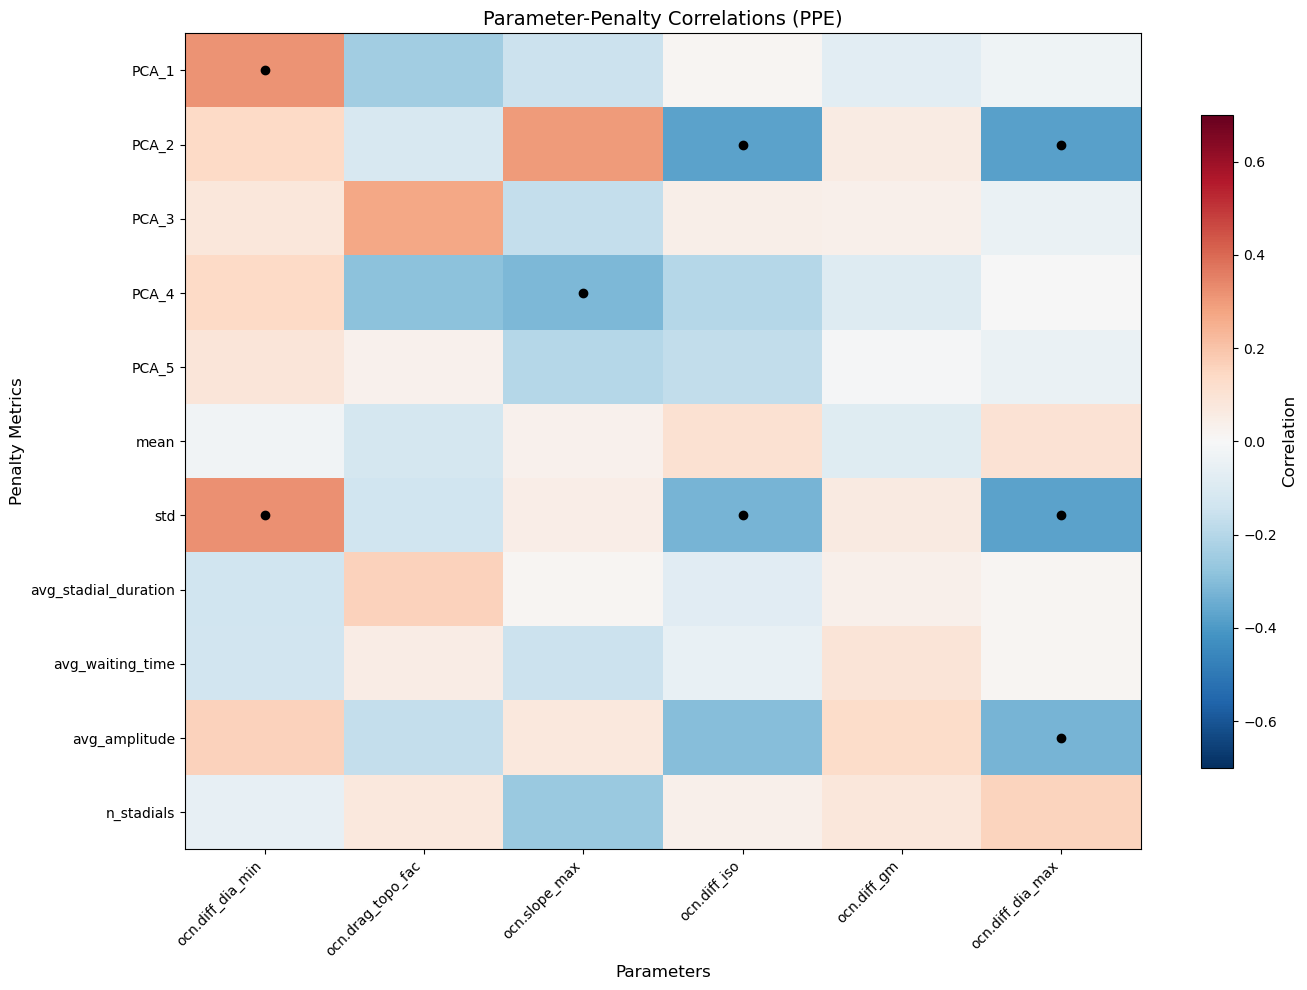

In [11]:
# # 7. Plot PPE Correlation Heatmap (Figure 2a/9a)

# %%
print("\n" + "="*70)
print("PPE CORRELATION ANALYSIS (Figure 2a)")
print("="*70)

correlations_ppe = plot_correlation_heatmap(
    X_valid, penalty_matrix, param_cols, output_names,
    title="Parameter-Penalty Correlations (PPE)"
)


TRAINING NN ENSEMBLE EMULATOR (Table 3)
Training NN 1/6: [64, 256, 256, 256] (relu)
Training NN 2/6: [64, 64, 64] (relu)
Training NN 3/6: [64, 128, 128] (relu)
Training NN 4/6: [64, 64, 64] (leaky_relu)
Training NN 5/6: [64, 64, 64, 64] (leaky_relu)
Training NN 6/6: [64, 128, 256, 512] (relu)
Ensemble of 6 NNs trained successfully.

EMULATOR EVALUATION

Metric                            R²         RMSE
--------------------------------------------------
PCA_1                          0.229       0.1212
PCA_2                          0.234       0.0962
PCA_3                          0.061       0.0649
PCA_4                          0.168       0.0480
PCA_5                         -0.099       0.0484
mean                           0.198       0.7859
std                            0.268       0.5145
avg_stadial_duration           0.229     221.8832
avg_waiting_time               0.203     382.2367
avg_amplitude                  0.258       1.7167
n_stadials                     0.182      

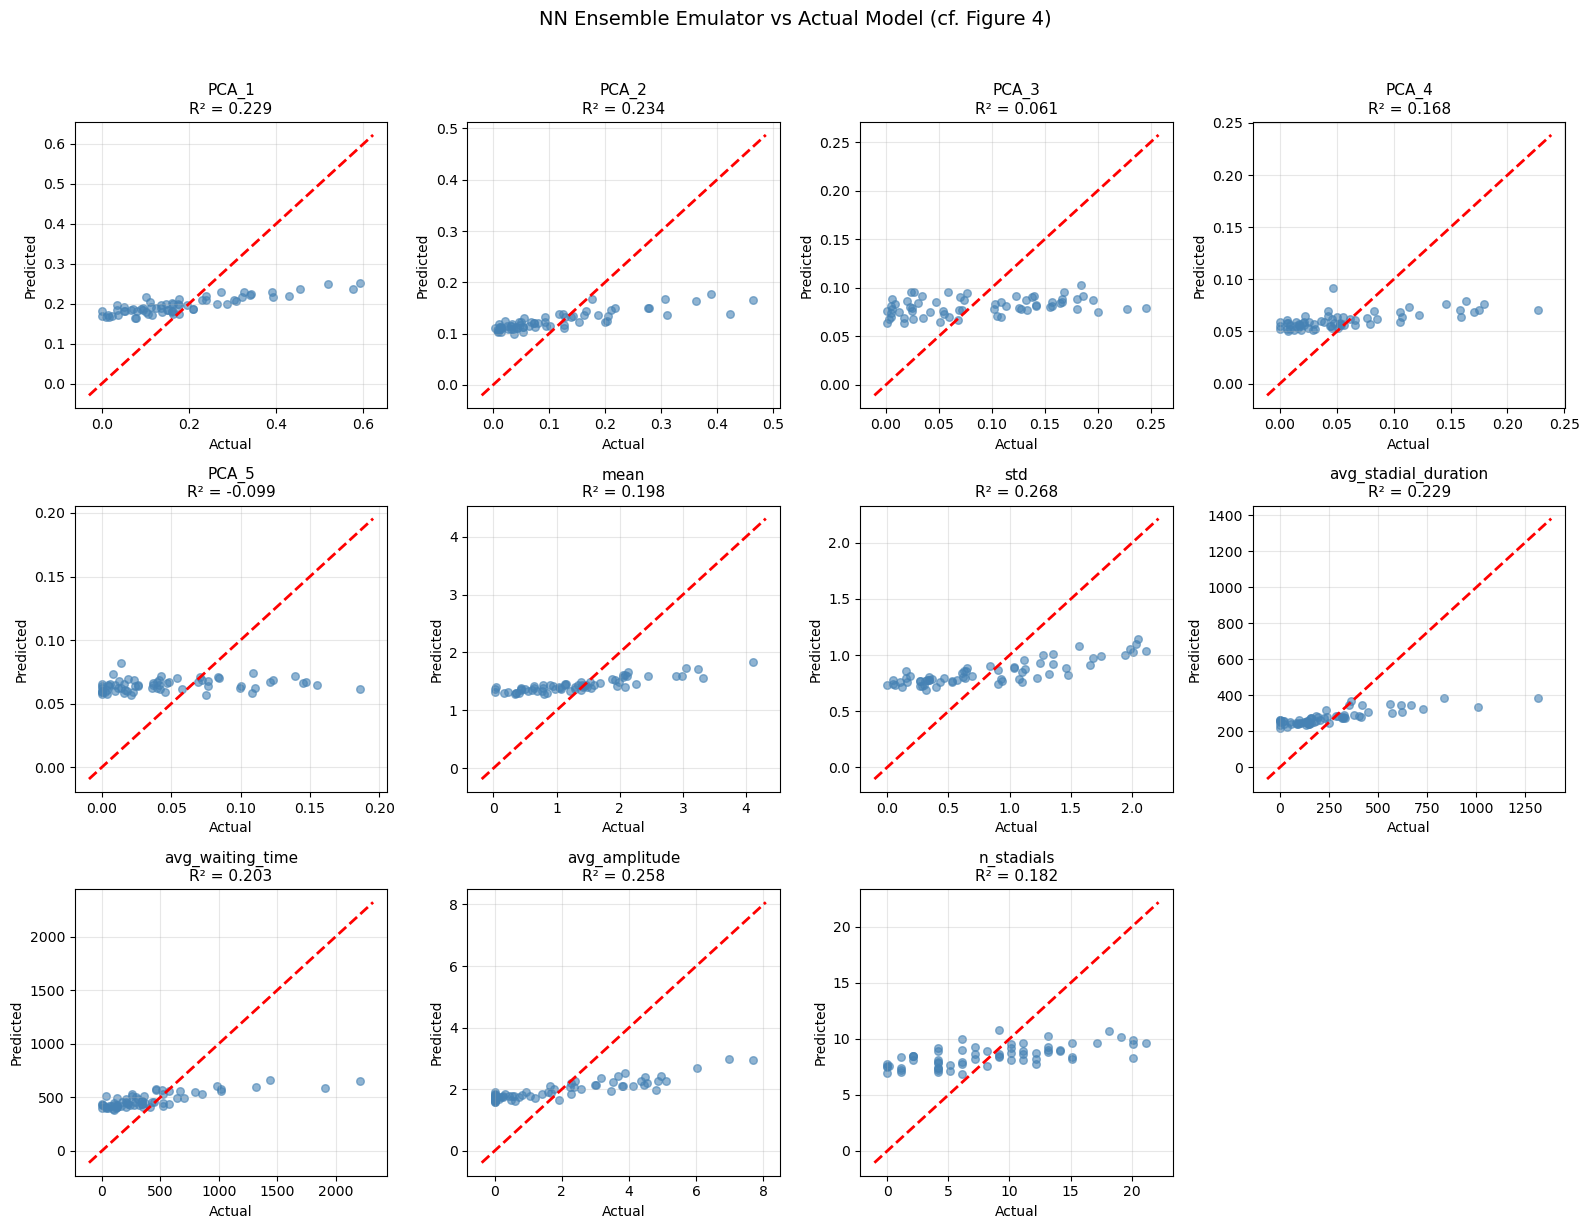

In [12]:
 # 8. Train NN Ensemble Emulator

# %%
print("\n" + "="*70)
print("TRAINING NN ENSEMBLE EMULATOR (Table 3)")
print("="*70)

emulator = NNEnsembleEmulator(
    n_inputs=X_train.shape[1],
    n_outputs=y_train.shape[1]
)

emulator.fit(X_train, y_train, epochs=500, verbose=0)

# %% [markdown]
# # 9. Evaluate Emulator (Figure 4)

# %%
print("\n" + "="*70)
print("EMULATOR EVALUATION")
print("="*70)

y_pred = emulator.predict(X_test)

# Print metrics
print(f"\n{'Metric':<25} {'R²':>10} {'RMSE':>12}")
print("-"*50)
for i, name in enumerate(output_names):
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    print(f"{name:<25} {r2:>10.3f} {rmse:>12.4f}")

# Plot
plot_emulator_validation(y_test, y_pred, output_names)

TRAINING SIMPLER NN ENSEMBLE
  Training NN 1/6: [32, 32]
    Stopped at epoch 1075, best val_loss: 0.487099
  Training NN 2/6: [64, 32]
    Stopped at epoch 100, best val_loss: 0.752532
  Training NN 3/6: [32, 16]
    Stopped at epoch 100, best val_loss: 0.822515
  Training NN 4/6: [64, 64]
    Stopped at epoch 100, best val_loss: 0.706578
  Training NN 5/6: [32, 32, 16]
    Stopped at epoch 100, best val_loss: 0.839423
  Training NN 6/6: [64]
    Stopped at epoch 100, best val_loss: 0.739380

  Ensemble trained.

EMULATOR EVALUATION

Metric                            R²         RMSE
--------------------------------------------------
PCA_1                          0.229       0.1212
PCA_2                          0.234       0.0962
PCA_3                          0.061       0.0649
PCA_4                          0.168       0.0480
PCA_5                         -0.099       0.0484
mean                           0.198       0.7859
std                            0.268       0.5145
avg_stad

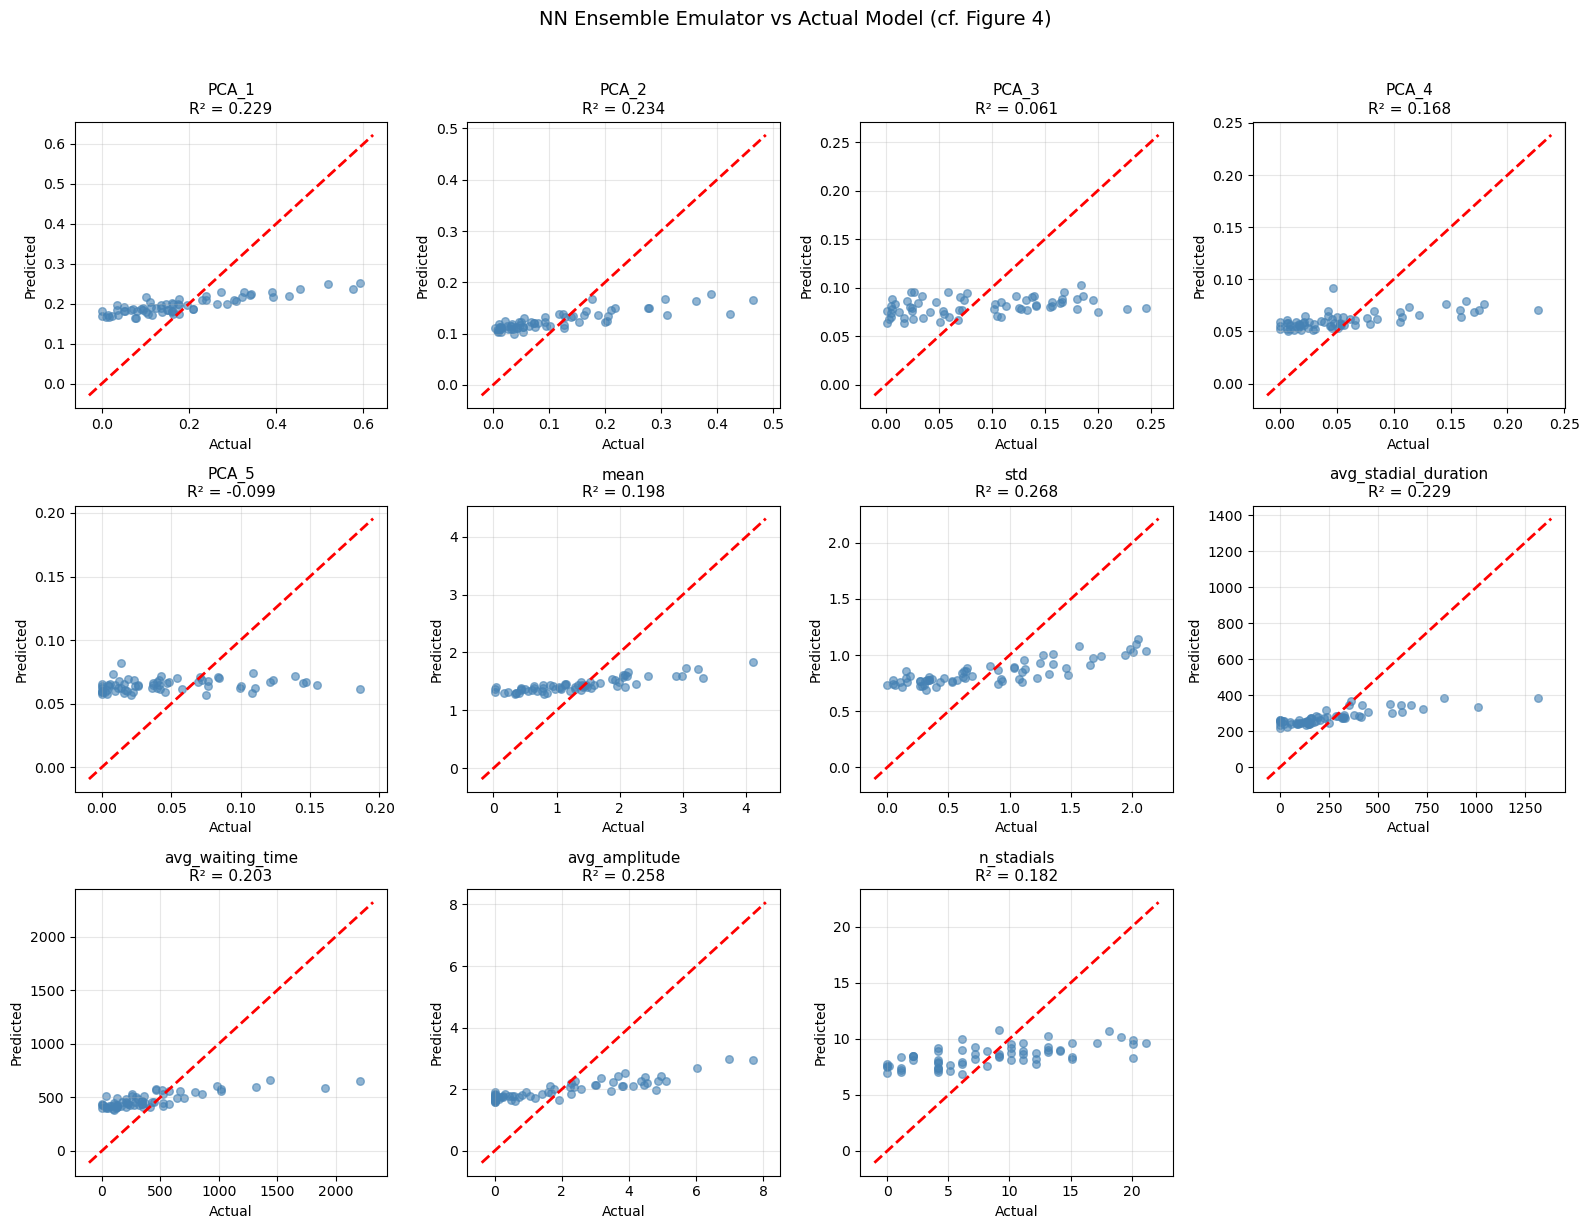

In [13]:
# %%
# SOLUTION 1: Use simpler NN architecture for small datasets
# Train with simpler architecture
print("="*70)
print("TRAINING SIMPLER NN ENSEMBLE")
print("="*70)

emulator_simple = NNEnsembleEmulatorSimple(
    n_inputs=X_train.shape[1],
    n_outputs=y_train.shape[1]
)

emulator_simple.fit(X_train, y_train, epochs=2000, verbose=0)

# # 9. Evaluate Emulator (Figure 4)

# %%
print("\n" + "="*70)
print("EMULATOR EVALUATION")
print("="*70)

y_pred = emulator.predict(X_test)

# Print metrics
print(f"\n{'Metric':<25} {'R²':>10} {'RMSE':>12}")
print("-"*50)
for i, name in enumerate(output_names):
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    print(f"{name:<25} {r2:>10.3f} {rmse:>12.4f}")

# Plot
plot_emulator_validation(y_test, y_pred, output_names)


PENALTY LANDSCAPES (Figure 3)


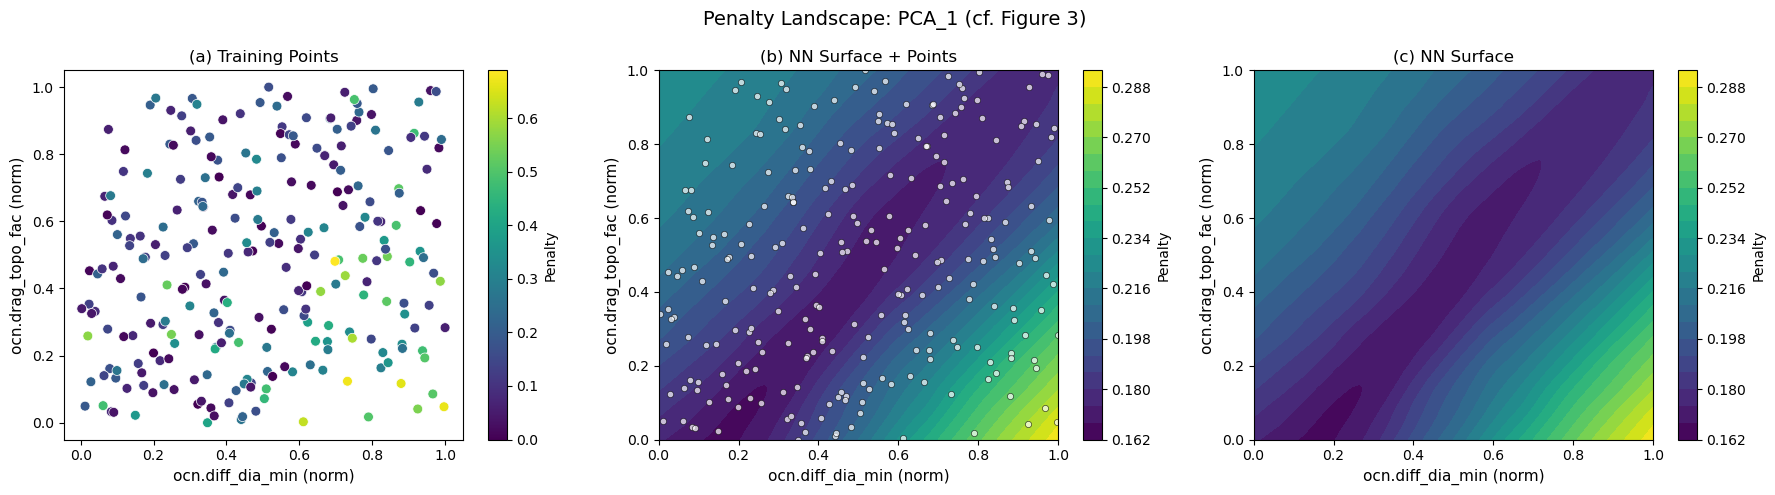

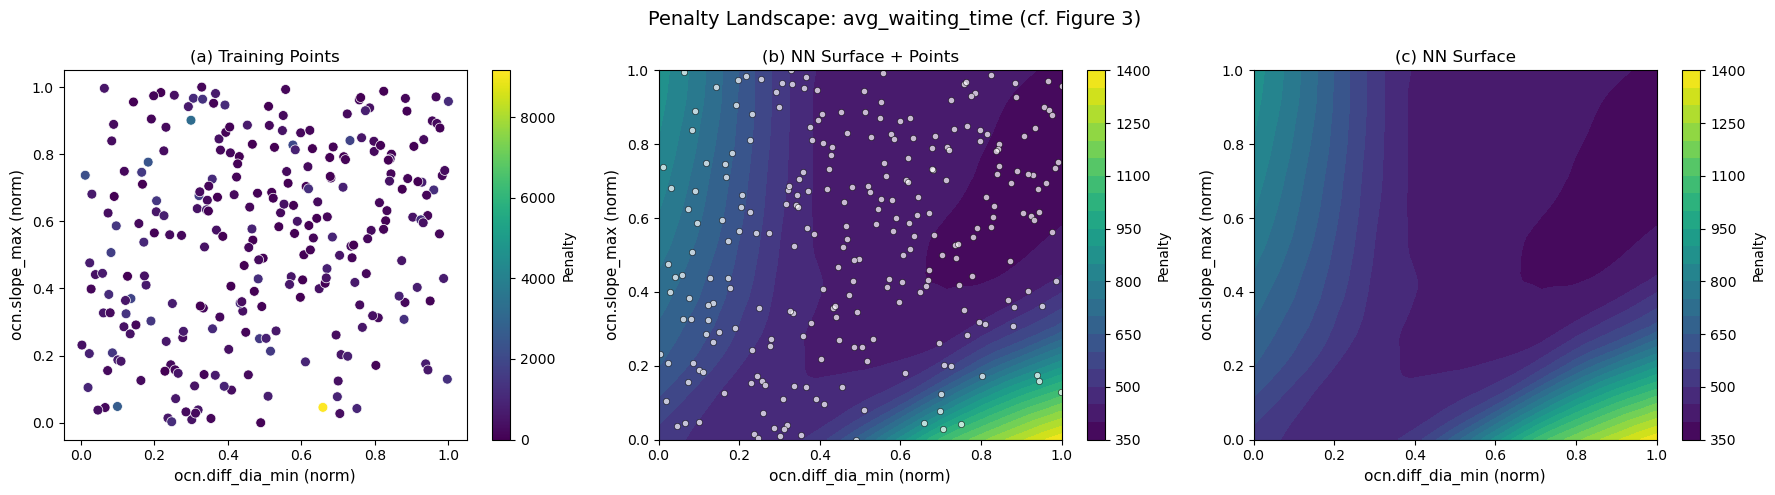

In [14]:
# # 10. Plot Penalty Landscapes (Figure 3)

# %%
print("\n" + "="*70)
print("PENALTY LANDSCAPES (Figure 3)")
print("="*70)

# Define parameter bounds
param_bounds = {col: (X_valid[:, i].min(), X_valid[:, i].max()) 
                for i, col in enumerate(param_cols)}

# Plot for first penalty metric (PCA_1) with first two parameters
plot_penalty_landscape_2d(
    emulator, X_train, y_train, param_cols, param_bounds,
    idx1=0, idx2=1, penalty_idx=0, penalty_name='PCA_1'
)

# Plot for waiting time penalty
wt_idx = output_names.index('avg_waiting_time')
plot_penalty_landscape_2d(
    emulator, X_train, y_train, param_cols, param_bounds,
    idx1=0, idx2=2, penalty_idx=wt_idx, penalty_name='avg_waiting_time'
)

In [15]:
# # # 12. Posterior Analysis

# %%
print("\n" + "="*70)
print("POSTERIOR PARAMETER SUMMARIES")
print("="*70)

print(f"\n{'Parameter':<25} {'Median':>15} {'16%':>15} {'84%':>15}")
print("-"*70)
for i, name in enumerate(param_cols):
    median = np.median(samples[:, i])
    low, high = np.percentile(samples[:, i], [16, 84])
    print(f"{name:<25} {median:>15.4e} {low:>15.4e} {high:>15.4e}")

# %% [markdown]
# # 13. CPE Correlation Heatmap (Figure 9b)

# %%
print("\n" + "="*70)
print("CPE CORRELATION ANALYSIS (Figure 9b)")
print("="*70)

# Predict penalties for posterior samples
n_posterior = min(500, len(samples))
idx = np.random.choice(len(samples), n_posterior, replace=False)
posterior_penalties = emulator.predict(samples[idx])

correlations_cpe = plot_correlation_heatmap(
    samples[idx], posterior_penalties, param_cols, output_names,
    title="Parameter-Penalty Correlations (CPE/Posterior)"
)11. MCMC Calibration (Equation 2)

# %%
print("\n" + "="*70)
print("MCMC CALIBRATION")
print("="*70)

# Compute tolerances from PPE (5th percentile - handles structural error)
tolerances = np.percentile(penalty_matrix, 5, axis=0)
tolerances = np.maximum(tolerances, 1e-6)

print("\nPenalty tolerances (5th percentile of PPE):")
for name, tol in zip(output_names, tolerances):
    print(f"  {name}: {tol:.4f}")

# %%
# Run MCMC
mcmc = MCMCCalibration(
    emulator=emulator,
    param_bounds=param_bounds,
    penalty_tolerances=tolerances,
    param_names=param_cols
)

samples, sampler = mcmc.run_mcmc(
    nwalkers=64, 
    nsteps=5000, 
    burn_in=1000, 
    thin=10,
    progress=True
)

print(f"\nPosterior samples: {samples.shape}")

SyntaxError: invalid syntax (3747427678.py, line 31)

In [ ]:
# # 14. Compare PPE vs CPE Correlations

# %%
print("\n" + "="*70)
print("PPE vs CPE CORRELATION COMPARISON")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PPE
ax = axes[0]
im = ax.imshow(correlations_ppe, cmap='RdBu_r', vmin=-0.7, vmax=0.7, aspect='auto')
ax.set_xticks(range(len(param_cols)))
ax.set_xticklabels(param_cols, rotation=45, ha='right')
ax.set_yticks(range(len(output_names)))
ax.set_yticklabels(output_names)
ax.set_title('PPE Correlations (Figure 9a)', fontsize=14)
for i in range(len(output_names)):
    for j in range(len(param_cols)):
        if np.abs(correlations_ppe[i, j]) > 0.3:
            ax.plot(j, i, 'ko', markersize=6)

# CPE
ax = axes[1]
im = ax.imshow(correlations_cpe, cmap='RdBu_r', vmin=-0.7, vmax=0.7, aspect='auto')
ax.set_xticks(range(len(param_cols)))
ax.set_xticklabels(param_cols, rotation=45, ha='right')
ax.set_yticks(range(len(output_names)))
ax.set_yticklabels(output_names)
ax.set_title('CPE Correlations (Figure 9b)', fontsize=14)
for i in range(len(output_names)):
    for j in range(len(param_cols)):
        if np.abs(correlations_cpe[i, j]) > 0.3:
            ax.plot(j, i, 'ko', markersize=6)

plt.colorbar(im, ax=axes, shrink=0.6, label='Correlation')
plt.suptitle('Parameter-Output Correlations: PPE vs CPE\n'
             '(Note: "unimportant" parameters become important after calibration)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# # 15. Posterior Histograms (Figure 10)

# %%
plot_posterior_histograms(samples, param_cols, param_bounds)

# %% [markdown]
# # 16. Corner Plot

# %%
if HAS_CORNER:
    fig = corner.corner(
        samples, 
        labels=param_cols,
        show_titles=True,
        title_fmt=".2e",
        quantiles=[0.16, 0.5, 0.84]
    )
    plt.suptitle('Posterior Corner Plot', fontsize=14, y=1.02)
    plt.show()
else:
    print("Install corner for corner plot: pip install corner")

# %% [markdown]
# # 17. Posterior Predictive Check

# %%
print("\n" + "="*70)
print("POSTERIOR PREDICTIVE CHECK")
print("="*70)

n_check = 100
idx = np.random.choice(len(samples), n_check, replace=False)
posterior_preds = emulator.predict(samples[idx])

print(f"\n{'Metric':<25} {'Target':>12} {'Post. Mean':>12} {'Post. Std':>12}")
print("-"*65)

# Target penalties are 0 (within obs bounds)
for i, name in enumerate(output_names):
    post_mean = posterior_preds[:, i].mean()
    post_std = posterior_preds[:, i].std()
    print(f"{name:<25} {0.0:>12.4f} {post_mean:>12.4f} {post_std:>12.4f}")

# %% [markdown]# # 18. Visualize Posterior Predictive PDFs

# %%
print("\n" + "="*70)
print("POSTERIOR PREDICTIVE PDFs")
print("="*70)

# Reconstruct PDFs from posterior PCA components
fig, ax = plt.subplots(figsize=(12, 6))

x_grid = default_stats['x_grid']

# Sample from posterior and reconstruct PDFs
n_samples_plot = 50
idx = np.random.choice(len(samples), n_samples_plot, replace=False)

for i, sample_idx in enumerate(idx):
    # Get predicted PCA penalties for this sample
    theta = samples[sample_idx:sample_idx+1]
    pred_penalties = emulator.predict(theta).flatten()
    
    # The first pdf_pca_components are PCA penalties
    # To reconstruct PDF, we need the actual PCA values, not penalties
    # This is approximate - penalties close to 0 mean PCA close to target
    
# Plot target PDF
ax.plot(x_grid, default_stats['pdf'], 'k-', linewidth=3, label='Target PDF')

ax.set_xlabel('AMOC (Sv)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Target PDF (Posterior predictive requires PCA reconstruction)', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# # 19. MCMC Diagnostics

# %%
print("\n" + "="*70)
print("MCMC DIAGNOSTICS")
print("="*70)

# Trace plots
fig, axes = plt.subplots(len(param_cols), 2, figsize=(14, 3*len(param_cols)))

chain = sampler.get_chain()

for i, name in enumerate(param_cols):
    # Trace
    ax = axes[i, 0]
    for j in range(min(10, chain.shape[1])):  # Plot 10 walkers
        ax.plot(chain[:, j, i], alpha=0.5)
    ax.set_ylabel(name, fontsize=10)
    ax.set_xlabel('Step', fontsize=10)
    ax.axvline(1000, color='red', linestyle='--', label='Burn-in')
    
    # Histogram
    ax = axes[i, 1]
    ax.hist(samples[:, i], bins=40, density=True, alpha=0.7)
    ax.set_xlabel(name, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)

plt.suptitle('MCMC Trace Plots and Posterior Histograms', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# # 20. Save Results

# %%
print("\n" + "="*70)
print("SAVING RESULTS")
print("="*70)

# Create results directory
os.makedirs('results_elsaesser', exist_ok=True)

# Save posterior samples
np.save('results_elsaesser/posterior_samples.npy', samples)

# Save parameter names and bounds
import json
with open('results_elsaesser/param_info.json', 'w') as f:
    json.dump({
        'param_names': param_cols,
        'param_bounds': {k: list(v) for k, v in param_bounds.items()},
        'output_names': output_names,
        'tolerances': tolerances.tolist()
    }, f, indent=2)

# Save summary statistics
summary = {
    'param': param_cols,
    'median': [np.median(samples[:, i]) for i in range(len(param_cols))],
    'p16': [np.percentile(samples[:, i], 16) for i in range(len(param_cols))],
    'p84': [np.percentile(samples[:, i], 84) for i in range(len(param_cols))],
}
pd.DataFrame(summary).to_csv('results_elsaesser/posterior_summary.csv', index=False)

print("Results saved to results_elsaesser/")

In [ ]:
# # 21. Summary

# %%
print("\n" + "="*70)
print("PIPELINE COMPLETE")
print("="*70)
print(f"""
Summary of Elsaesser et al. (2025) Pipeline:

1. Data: {X_valid.shape[0]} DO-oscillating runs with {len(param_cols)} parameters

2. Penalty Metrics: {len(output_names)} outputs
   - {pdf_pca_components} PCA components (PDF shape)
   - {len(scalar_stat_names)} scalar statistics

3. NN Ensemble Emulator:
   - 6 NNs with different architectures (Table 3)
   - Ensemble average reduces overfitting
   - Mean R² across outputs: {np.mean([r2_score(y_test[:, i], y_pred[:, i]) for i in range(len(output_names))]):.3f}

4. MCMC Calibration:
   - Likelihood: N(0, 0.5*tolerance) for each penalty
   - Tolerances from 5th percentile of PPE (handles structural error)
   - Posterior samples: {samples.shape[0]}

5. Key Insights:
   - PPE vs CPE correlations show "unimportant" parameters become important
   - Penalty function has flat bottom (no penalty within obs bounds)
   - Tolerance inflation accounts for model structural error
""")